# Simple Image Segmentation Training Notebook

This notebook is a **simple training notebook** for students who are learning **classical image segmentation**.

## What students will learn
- how to download a dataset from Kaggle
- how to save it into Google Drive
- how to read images and masks
- how to segment objects using simple image processing
- how to compare predicted masks with true masks
- how to calculate basic segmentation metrics

## Method used
This notebook uses only **classical image processing**:
- grayscale conversion
- thresholding
- morphology
- connected components

It does **not** use deep learning.

## Dataset used
This notebook is prepared for a **small Kaggle segmentation dataset**.

You can use it in **Google Colab**.

The notebook:
1. mounts Google Drive
2. downloads the dataset from Kaggle
3. copies it into Google Drive
4. loads image-mask pairs
5. performs simple segmentation

## Step 1: Install package
If needed, install `kagglehub`.

In [1]:
# Uncomment this in Google Colab if needed
# !pip install -q kagglehub

## Step 2: Import libraries
These libraries are enough for a simple segmentation project.

In [3]:
import os
import re
import cv2
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import kagglehub

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["image.cmap"] = "gray"

## Step 3: Mount Google Drive
This allows the files and results to stay saved.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 4: Download dataset from Kaggle
The dataset is downloaded first, then copied into Google Drive.

In [5]:
DOWNLOAD_DIR = Path(
    kagglehub.dataset_download("nizier193/leaf-segmentation-dataset-mk7")
)

print("Downloaded to:", DOWNLOAD_DIR)

DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/simple_segmentation_training")
DRIVE_PROJECT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_DIR = DRIVE_PROJECT_DIR / "dataset"

if not DATASET_DIR.exists():
    shutil.copytree(DOWNLOAD_DIR, DATASET_DIR)
    print("Copied dataset to Drive:", DATASET_DIR)
else:
    print("Dataset already exists in Drive:", DATASET_DIR)

100%|██████████| 22.7M/22.7M [00:00<00:00, 234MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/nizier193/leaf-segmentation-dataset-mk7/versions/1
Copied dataset to Drive: /content/drive/MyDrive/simple_segmentation_training/dataset


## Step 5: Inspect the dataset folders
This helps students understand the dataset structure.

In [6]:
for root, dirs, files in os.walk(DATASET_DIR):
    level = root.replace(str(DATASET_DIR), "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{Path(root).name}/")
    for f in files[:3]:
        print(" " * 2 * (level + 1) + f)
    if level >= 2:
        continue

dataset/
  aug/
    masks/
      mask-9-1.jpg
      mask-66-0.jpg
      mask-116-0.jpg
    images/
      image-248-1.jpg
      image-6-1.jpg
      image-114-1.jpg


## Step 6: Find image and mask folders
This cell tries to automatically detect where images and masks are stored.

In [7]:
image_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

all_dirs = [p for p in DATASET_DIR.rglob("*") if p.is_dir()]

def count_images(folder):
    return len([p for p in folder.glob("*") if p.suffix.lower() in image_exts])

image_candidates = []
mask_candidates = []

for d in all_dirs:
    name = d.name.lower()
    n_files = count_images(d)
    if n_files == 0:
        continue

    if any(k in name for k in ["image", "images", "img", "rgb"]):
        image_candidates.append((d, n_files))
    if any(k in name for k in ["mask", "masks", "label", "labels", "annotation", "annotations"]):
        mask_candidates.append((d, n_files))

print("Image candidates:")
for d, n in image_candidates[:10]:
    print("-", d, "|", n)

print("\nMask candidates:")
for d, n in mask_candidates[:10]:
    print("-", d, "|", n)

Image candidates:
- /content/drive/MyDrive/simple_segmentation_training/dataset/aug/images | 552

Mask candidates:
- /content/drive/MyDrive/simple_segmentation_training/dataset/aug/masks | 552


## Step 7: Select the folders
The notebook chooses the folder with the highest number of image files.

In [8]:
IMAGE_DIR = sorted(image_candidates, key=lambda x: x[1], reverse=True)[0][0]
MASK_DIR = sorted(mask_candidates, key=lambda x: x[1], reverse=True)[0][0]

print("IMAGE_DIR:", IMAGE_DIR)
print("MASK_DIR :", MASK_DIR)

IMAGE_DIR: /content/drive/MyDrive/simple_segmentation_training/dataset/aug/images
MASK_DIR : /content/drive/MyDrive/simple_segmentation_training/dataset/aug/masks


## Step 8: Helper functions
These functions make reading and visualization easier.

In [9]:
def read_image(path, size=(256, 256)):
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    return img

def read_mask(path, size=(256, 256)):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, size)
    _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    return mask

def show_many(images, titles, cols=3, size=(15, 8)):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=size)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(img)
        plt.title(titles[i])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def overlay_mask(image, mask, color=(255, 0, 0), alpha=0.35):
    out = image.copy()
    color_layer = np.zeros_like(image)
    color_layer[:, :] = color
    mask_bool = mask > 0
    out[mask_bool] = cv2.addWeighted(image[mask_bool], 1-alpha, color_layer[mask_bool], alpha, 0)
    return out

## Step 9: Build image-mask pairs
The filenames may start with different words like `image-` and `mask-`, so we match them using the numeric part.

In [10]:
def list_image_files(folder):
    return sorted([p for p in folder.rglob("*") if p.suffix.lower() in image_exts])

def extract_id(name):
    name = Path(name).stem.lower()
    m = re.search(r"(\d+-\d+)$", name)
    if m:
        return m.group(1)

    nums = re.findall(r"\d+", name)
    if len(nums) >= 2:
        return f"{nums[-2]}-{nums[-1]}"
    elif len(nums) == 1:
        return nums[0]
    return name

def build_pairs(image_dir, mask_dir):
    image_files = list_image_files(image_dir)
    mask_files = list_image_files(mask_dir)

    mask_map = {}
    for m in mask_files:
        mask_map[extract_id(m.name)] = m

    pairs = []
    for img_path in image_files:
        key = extract_id(img_path.name)
        if key in mask_map:
            pairs.append((img_path, mask_map[key]))

    return pairs

pairs = build_pairs(IMAGE_DIR, MASK_DIR)

print("Images found:", len(list_image_files(IMAGE_DIR)))
print("Masks found :", len(list_image_files(MASK_DIR)))
print("Pairs found :", len(pairs))

Images found: 552
Masks found : 552
Pairs found : 552


## Step 10: Preview one image and its mask
This is a simple way to verify that pairing is correct.

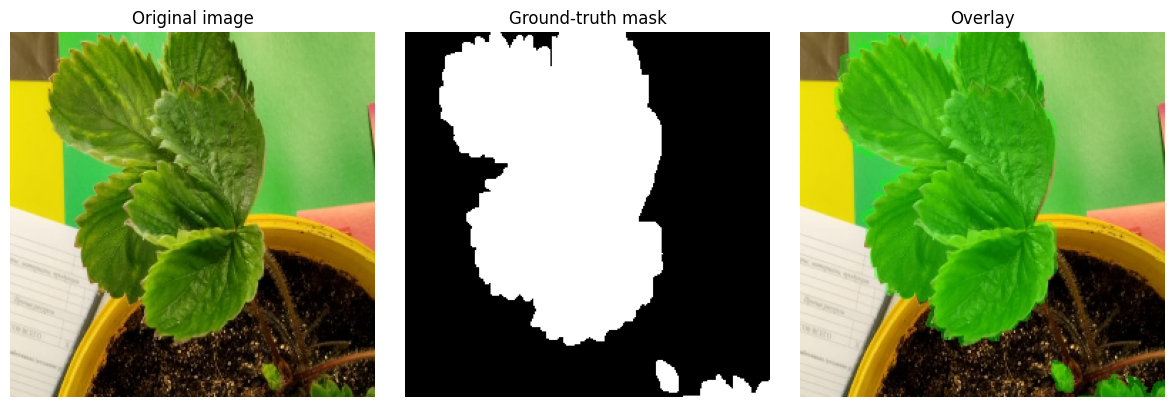

Image: image-0-0.jpg
Mask : mask-0-0.jpg


In [11]:
if len(pairs) == 0:
    raise ValueError("No image-mask pairs found. Check IMAGE_DIR and MASK_DIR.")

img_path, mask_path = pairs[0]

img = read_image(img_path)
gt = read_mask(mask_path)
over = overlay_mask(img, gt, color=(0, 255, 0))

show_many(
    [img, gt, over],
    ["Original image", "Ground-truth mask", "Overlay"],
    cols=3,
    size=(12, 4)
)

print("Image:", img_path.name)
print("Mask :", mask_path.name)

# Simple segmentation method

## Idea
We will use a very simple pipeline:
1. convert to grayscale
2. blur the image
3. apply thresholding
4. clean the mask using morphology
5. keep the largest object

This is a good beginner method.

In [12]:
def largest_component(binary):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if num_labels <= 1:
        return binary

    areas = stats[1:, cv2.CC_STAT_AREA]
    largest_idx = 1 + np.argmax(areas)

    out = np.zeros_like(binary)
    out[labels == largest_idx] = 255
    return out

def segment_simple(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    _, mask = cv2.threshold(
        blur, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    mask = largest_component(mask)
    return gray, blur, mask

## Step 11: Apply simple segmentation to one image

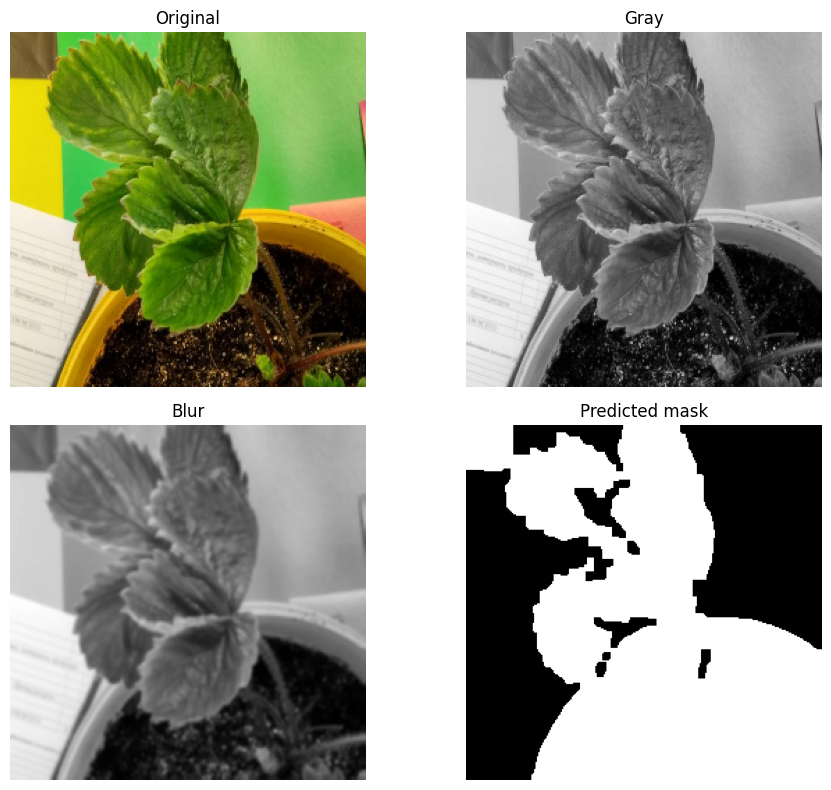

In [13]:
gray, blur, pred = segment_simple(img)

show_many(
    [img, gray, blur, pred],
    ["Original", "Gray", "Blur", "Predicted mask"],
    cols=2,
    size=(10, 8)
)

## Step 12: Compare true mask and predicted mask

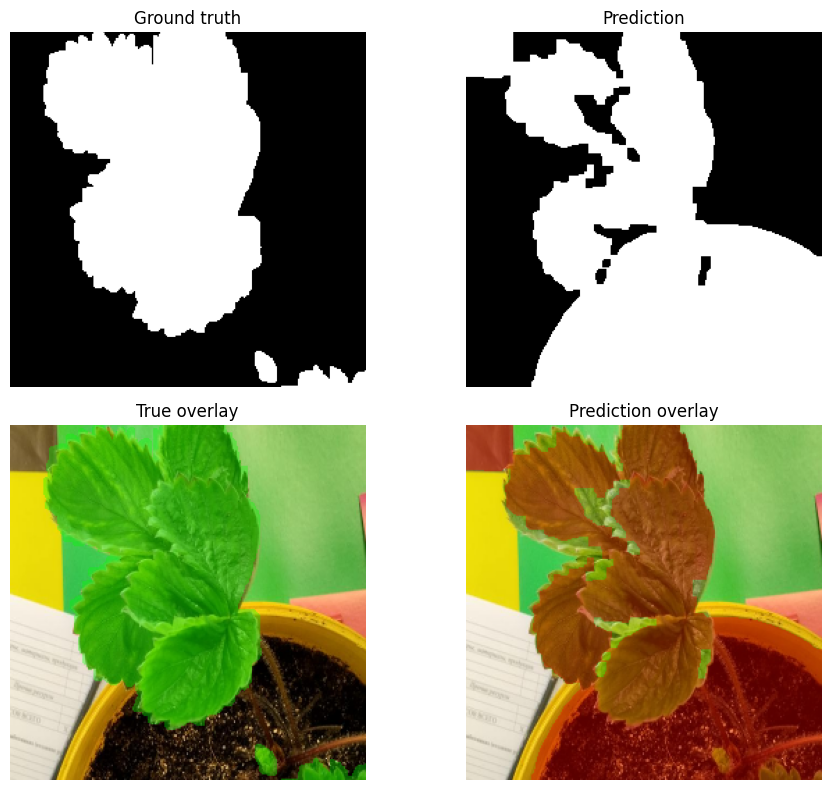

In [14]:
show_many(
    [gt, pred, overlay_mask(img, gt, color=(0, 255, 0)), overlay_mask(img, pred, color=(255, 0, 0))],
    ["Ground truth", "Prediction", "True overlay", "Prediction overlay"],
    cols=2,
    size=(10, 8)
)

# Metrics

We now calculate basic segmentation metrics.

## Metrics used
- Accuracy
- Precision
- Recall
- F1-score
- IoU
- Dice

In [15]:
def to_binary(mask):
    return (mask > 0).astype(np.uint8)

def segmentation_metrics(y_true, y_pred):
    y_true = to_binary(y_true).flatten()
    y_pred = to_binary(y_pred).flatten()

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)
    dice = 2 * tp / (2 * tp + fp + fn + 1e-8)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "iou": iou,
        "dice": dice
    }

## Step 13: Measure metrics for one image

In [16]:
metrics = segmentation_metrics(gt, pred)

for k, v in metrics.items():
    print(f"{k:10s}: {v:.4f}")

accuracy  : 0.7066
precision : 0.5993
recall    : 0.8383
f1_score  : 0.6990
iou       : 0.5372
dice      : 0.6990


## Step 14: Evaluate several images
This helps students see average performance.

In [17]:
results = []

for img_path, mask_path in pairs[:50]:
    img = read_image(img_path)
    gt = read_mask(mask_path)
    _, _, pred = segment_simple(img)

    m = segmentation_metrics(gt, pred)
    row = {"image": img_path.name}
    row.update(m)
    results.append(row)

df = pd.DataFrame(results)
df.head()

,image,accuracy,precision,recall,f1_score,iou,dice
0,image-0-0.jpg,0.706558,0.599345,0.838277,0.698956,0.537227,0.698956
1,image-0-1.jpg,0.605835,0.732726,0.718291,0.725437,0.569165,0.725437
2,image-1-0.jpg,0.688293,0.470018,0.950381,0.628973,0.458761,0.628973
3,image-1-1.jpg,0.668976,0.418026,0.836486,0.557464,0.386447,0.557464
4,image-10-0.jpg,0.705688,0.713589,0.640945,0.675319,0.509797,0.675319


## Step 15: Average results

In [18]:
summary = df.mean(numeric_only=True)
summary

,0
accuracy,0.678429
precision,0.694515
recall,0.659454
f1_score,0.622773
iou,0.492889
dice,0.622773


## Step 16: Save results to Google Drive

In [19]:
RESULTS_DIR = DRIVE_PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(RESULTS_DIR / "simple_segmentation_results.csv", index=False)

print("Saved to:", RESULTS_DIR / "simple_segmentation_results.csv")

Saved to: /content/drive/MyDrive/simple_segmentation_training/results/simple_segmentation_results.csv


# Training questions for students

1. Why do we convert the image to grayscale?
2. Why do we apply Gaussian blur?
3. What does Otsu thresholding do?
4. Why do we use opening and closing?
5. Why do we keep the largest component?
6. Which metric is more useful: IoU or Dice?
7. In which cases might this simple method fail?

# Small practice tasks

## Task 1
Change the kernel size from `(5,5)` to `(3,3)` and compare the result.

## Task 2
Try `cv2.THRESH_BINARY` instead of `cv2.THRESH_BINARY_INV`.

## Task 3
Test the method on 10 more images and compare the metrics.

## Task 4
Display 3 success cases and 3 failure cases.

## Task 5
Try adaptive thresholding and compare it with Otsu thresholding.

# Final note

This notebook is intentionally simple for training.

It is useful for:
- beginner image segmentation
- understanding masks
- learning thresholding
- learning morphology
- evaluating segmentation results

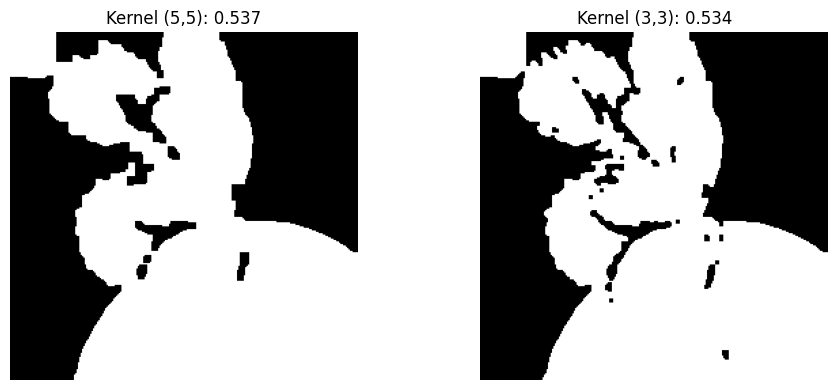

Task 1: Kernel size comparison ===
Metric         Kernel (5,5)   Kernel (3,3)
accuracy             0.7066         0.7042
precision            0.5993         0.5976
recall               0.8383         0.8329
f1_score             0.6990         0.6959
iou                  0.5372         0.5337
dice                 0.6990         0.6959


In [20]:
#TASK 1 - Change kernel size (5,5) → (3,3) and compare

def segment_kernel3(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    kernel = np.ones((3, 3), np.uint8)   #changed from (5,5) to (3,3)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = largest_component(mask)
    return mask

img_path, mask_path = pairs[0]
img_t1 = read_image(img_path)
gt_t1  = read_mask(mask_path)

_, _, pred_k5 = segment_simple(img_t1)    # original kernel (5,5)
pred_k3       = segment_kernel3(img_t1)   # new kernel (3,3)

metrics_k5 = segmentation_metrics(gt_t1, pred_k5)
metrics_k3 = segmentation_metrics(gt_t1, pred_k3)

show_many(
    [pred_k5, pred_k3],
    [f"Kernel (5,5): {metrics_k5['iou']:.3f}",
     f"Kernel (3,3): {metrics_k3['iou']:.3f}"],
    cols=2, size=(10, 4)
)

print("Task 1: Kernel size comparison")
print(f"{'Metric':<12} {'Kernel (5,5)':>14} {'Kernel (3,3)':>14}")
for k in metrics_k5:
    print(f"{k:<12} {metrics_k5[k]:>14.4f} {metrics_k3[k]:>14.4f}")

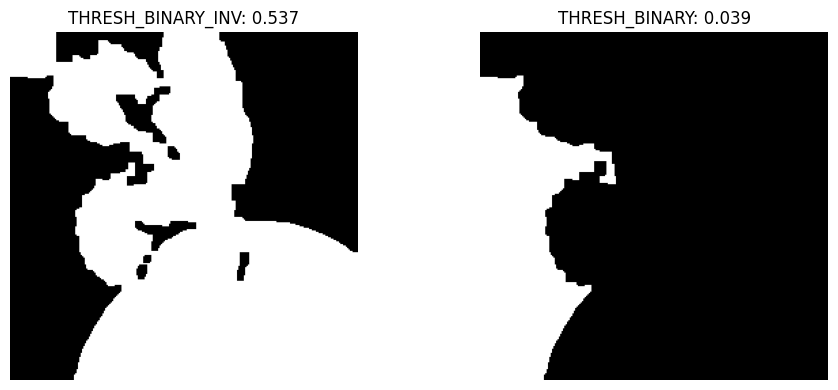


 Task 2: Threshold type comparison
Metric           BINARY_INV         BINARY
accuracy             0.7066         0.4447
precision            0.5993         0.1151
recall               0.8383         0.0548
f1_score             0.6990         0.0742
iou                  0.5372         0.0385
dice                 0.6990         0.0742


In [21]:
#TASK 2 - THRESH_BINARY instead of THRESH_BINARY_INV

def segment_binary(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    _, mask = cv2.threshold(blur, 0, 255,
                            cv2.THRESH_BINARY + cv2.THRESH_OTSU)  #no INV

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = largest_component(mask)
    return mask

img_path, mask_path = pairs[0]
img_t2 = read_image(img_path)
gt_t2  = read_mask(mask_path)

_, _, pred_inv    = segment_simple(img_t2)   # THRESH_BINARY_INV
pred_no_inv       = segment_binary(img_t2)   # THRESH_BINARY

metrics_inv    = segmentation_metrics(gt_t2, pred_inv)
metrics_no_inv = segmentation_metrics(gt_t2, pred_no_inv)

show_many(
    [pred_inv, pred_no_inv],
    [f"THRESH_BINARY_INV: {metrics_inv['iou']:.3f}",
     f"THRESH_BINARY: {metrics_no_inv['iou']:.3f}"],
    cols=2, size=(10, 4)
)

print("\n Task 2: Threshold type comparison")
print(f"{'Metric':<12} {'BINARY_INV':>14} {'BINARY':>14}")
for k in metrics_inv:
    print(f"{k:<12} {metrics_inv[k]:>14.4f} {metrics_no_inv[k]:>14.4f}")

In [22]:
# TASK 3 — Test on 10 more images and compare metrics

extra_pairs = pairs[1:11]

results_extra = []
for img_path, mask_path in extra_pairs:
    img_e = read_image(img_path)
    gt_e  = read_mask(mask_path)
    _, _, pred_e = segment_simple(img_e)
    m = segmentation_metrics(gt_e, pred_e)
    row = {"image": img_path.name}
    row.update(m)
    results_extra.append(row)

df_extra = pd.DataFrame(results_extra)

print("\nTask 3: Results for 10 extra images")
print(df_extra.to_string(index=False))
print("\nAverage")
print(df_extra.mean(numeric_only=True).to_string())



Task 3: Results for 10 extra images
          image  accuracy  precision   recall  f1_score      iou     dice
  image-0-1.jpg  0.605835   0.732726 0.718291  0.725437 0.569165 0.725437
  image-1-0.jpg  0.688293   0.470018 0.950381  0.628973 0.458761 0.628973
  image-1-1.jpg  0.668976   0.418026 0.836486  0.557464 0.386447 0.557464
 image-10-0.jpg  0.705688   0.713589 0.640945  0.675319 0.509797 0.675319
image-100-0.jpg  0.600357   0.366285 0.603752  0.455952 0.295297 0.455952
image-100-1.jpg  0.489838   0.235218 0.979107  0.379312 0.234044 0.379312
image-101-0.jpg  0.608078   0.997026 0.557100  0.714798 0.556176 0.714798
image-101-1.jpg  0.898727   0.998575 0.836233  0.910222 0.835237 0.910222
image-102-0.jpg  0.646225   0.253141 0.962522  0.400858 0.250671 0.400858
image-102-1.jpg  0.793991   0.695225 0.909766  0.788156 0.650378 0.788156

Average
accuracy     0.670601
precision    0.587983
recall       0.799458
f1_score     0.623649
iou          0.474597
dice         0.623649



Task 4: Success cases (highest IoU)


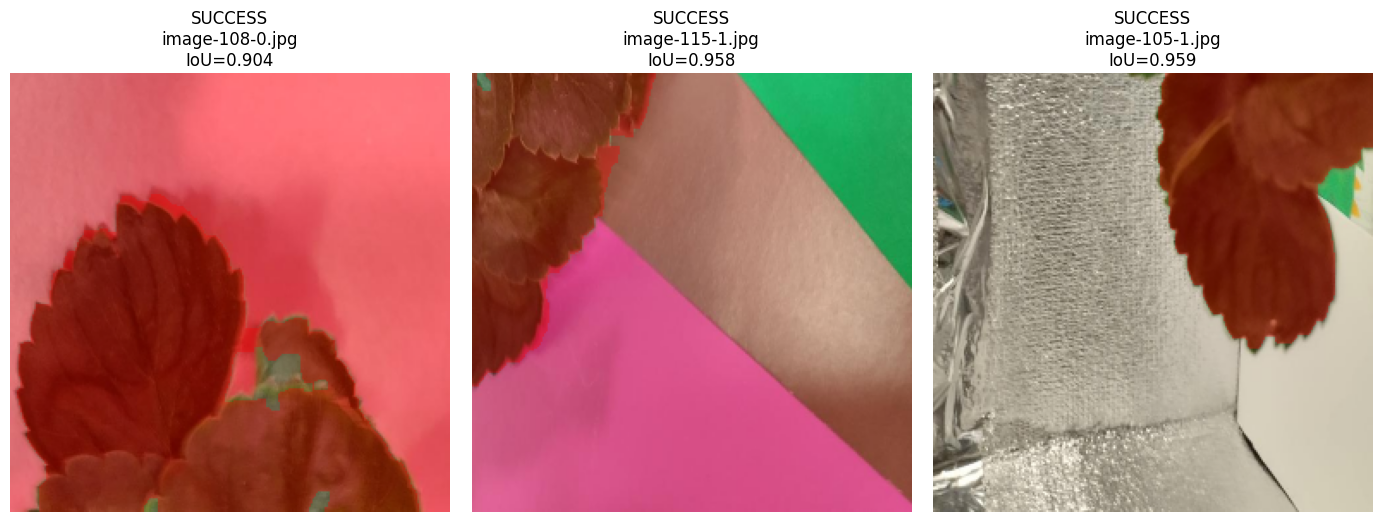

Task 4: Failure cases (lowest IoU)


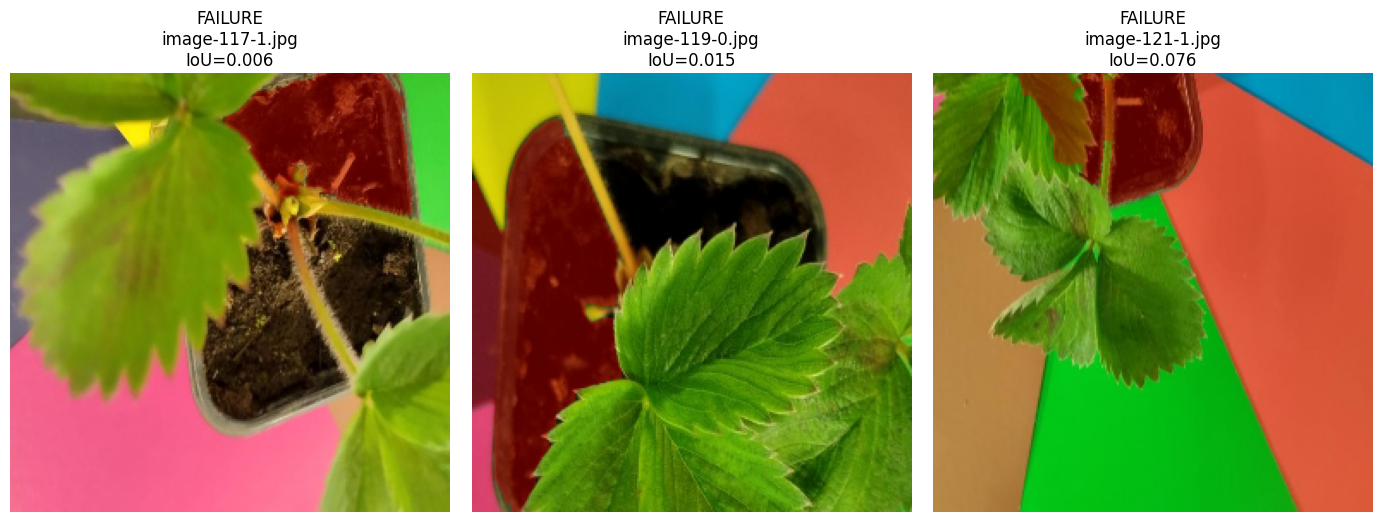

In [23]:
# TASK 4 — Display 3 success cases and 3 failure cases


#Evaluate all available pairs (up to 50) and rank by IoU
eval_results = []
for img_path, mask_path in pairs[:50]:
    img_e = read_image(img_path)
    gt_e  = read_mask(mask_path)
    _, _, pred_e = segment_simple(img_e)
    m = segmentation_metrics(gt_e, pred_e)
    eval_results.append({
        "img_path": img_path,
        "mask_path": mask_path,
        "iou": m["iou"]
    })

eval_results.sort(key=lambda x: x["iou"])

failure_cases = eval_results[:3]   # lowest IoU
success_cases = eval_results[-3:]  # highest IoU

def show_cases(cases, label):
    imgs, titles = [], []
    for case in cases:
        img_c  = read_image(case["img_path"])
        gt_c   = read_mask(case["mask_path"])
        _, _, pred_c = segment_simple(img_c)
        imgs.append(overlay_mask(img_c, pred_c, color=(255, 0, 0)))
        titles.append(f"{label}\n{case['img_path'].name}\nIoU={case['iou']:.3f}")
    show_many(imgs, titles, cols=3, size=(14, 5))

print("\nTask 4: Success cases (highest IoU)")
show_cases(success_cases, "SUCCESS")

print("Task 4: Failure cases (lowest IoU)")
show_cases(failure_cases, "FAILURE")


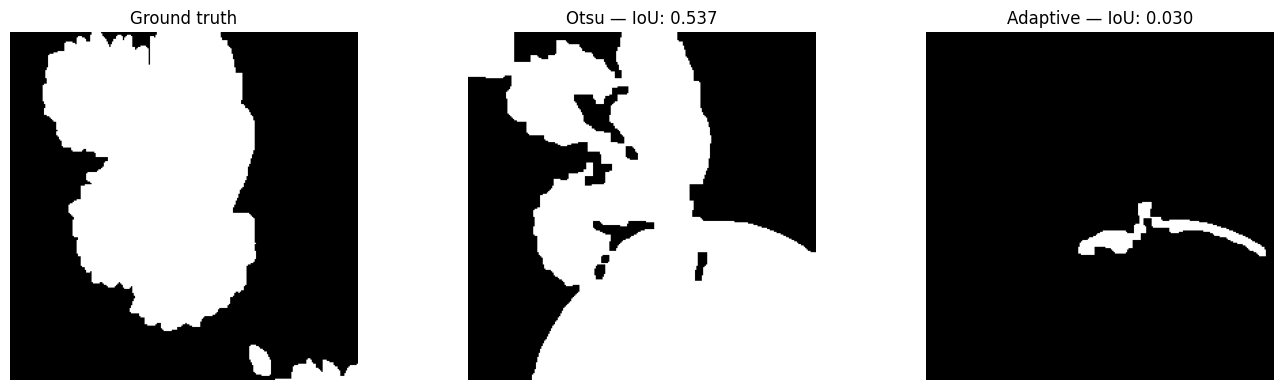


Task 5: Otsu vs Adaptive (average over 10 images)
Metric             Otsu   Adaptive
accuracy         0.6619     0.5696
precision        0.5784     0.4460
recall           0.7923     0.0349
f1_score         0.6147     0.0620
iou              0.4633     0.0330
dice             0.6147     0.0620


In [24]:
# TASK 5 — Adaptive thresholding vs Otsu


def segment_adaptive(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)


    mask = cv2.adaptiveThreshold(
        blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        blockSize=31,
        C=5
    )

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = largest_component(mask)
    return mask

# Compare
results_otsu     = []
results_adaptive = []

for img_path, mask_path in pairs[:10]:
    img_t5 = read_image(img_path)
    gt_t5  = read_mask(mask_path)

    _, _, pred_otsu = segment_simple(img_t5)
    pred_adapt      = segment_adaptive(img_t5)

    results_otsu.append(segmentation_metrics(gt_t5, pred_otsu))
    results_adaptive.append(segmentation_metrics(gt_t5, pred_adapt))

df_otsu     = pd.DataFrame(results_otsu)
df_adaptive = pd.DataFrame(results_adaptive)

# Visual comparison
img_t5 = read_image(pairs[0][0])
gt_t5  = read_mask(pairs[0][1])
_, _, pred_otsu5 = segment_simple(img_t5)
pred_adapt5      = segment_adaptive(img_t5)

show_many(
    [gt_t5, pred_otsu5, pred_adapt5],
    ["Ground truth",
     f"Otsu — IoU: {segmentation_metrics(gt_t5, pred_otsu5)['iou']:.3f}",
     f"Adaptive — IoU: {segmentation_metrics(gt_t5, pred_adapt5)['iou']:.3f}"],
    cols=3, size=(14, 4)
)

print("\nTask 5: Otsu vs Adaptive (average over 10 images)")
print(f"{'Metric':<12} {'Otsu':>10} {'Adaptive':>10}")
for k in ["accuracy", "precision", "recall", "f1_score", "iou", "dice"]:
    print(f"{k:<12} {df_otsu[k].mean():>10.4f} {df_adaptive[k].mean():>10.4f}")
